# SWDM2013

---

## A. Original description

#### Meta Information:

- We used paid workers from the Crowdflower crowdsourcing platform for labeling
- At least three different workers were required to agree on a label before a task is finalized
- We ran two tasks (as described below) for labeling


####  Task # 1 Categories---Description:

1. Personal Only---if a message is only of interest to its author and her immediate circle of family/friends and does not convey any useful information to other people who do not know the author.
2. Informative (Direct)--- if the message is of interest to other people beyond the author's immediate circle, and seems to be written by a person who is a direct eyewitness of what is taking place.
3. Informative (Indirect)--- if the message is of interest to other people beyond the author's immediate circle, and seems to be seen/heard by the person on the radio, TV, newspaper, or other source. The message must specify the source.
4. Informative (Direct or Indirect)--- if the message is of interest to other people beyond the author's immediate circle, but there is not enough information to tell if it is a direct report or a repetition of something from another source.
5. Other--- if the message is not in English, or if it cannot be classified.


####  Task # 2 Categories---Description:

1. Caution and advice---if a message conveys/reports information about some warning or a piece of advice about a possible hazard of an incident.
2. Casualties and damage---if a message reports the information about casualties or damage done by an incident.
3. Donations of money, goods or services---if a message speaks about money raised, donation offers, goods/services offered or asked by the victims of an incident.
4. People missing, found, or seen---if a message reports about the missing or found person effected by an incident or seen a celebrity visit on ground zero.
5. Information source---if a message conveys/contains some information sources like photo, footage, video, or mentions other sources like TV, radio related to an incident.

#### Reference

Muhammad Imran, Shady Elbassuoni, Carlos Castillo, Fernando Diaz and Patrick Meier. Practical Extraction of Disaster-Relevant Information from Social Media. In Social Web for Disaster Management (SWDM'13) - Co-located with WWW, May 2013, Rio de Janeiro, Brazil. 



## B. Overview

In [1]:
from pathlib import Path
import os

import random
random.seed(42)

import pandas as pd
import numpy as np

from dotenv import load_dotenv
load_dotenv()

True

In [2]:


dataset_path = Path(os.getenv("DATASETS_PATH")) / 'SWDM2013' / 'SWDM2013_dataset' / 'sandy2012_labeled_data'

files = [
    '01_personal-informative-other/a143145.csv',
    '02_informative_caution-infosrc-donation-damage-other/a144267.csv',
    # '03_caution-n-advice_classify-extract/a146283.csv',
    # '03_damage-n-casualties_classify-extract/a146281.csv',
    # '03_infosrc_classify-extract/a146274.csv',
    # '04_combined_classification/a154774.csv',
    # '04_combined_classification/f154774.csv',
    # '05_information_extraction/f157060.csv',
]

#### Task 1

In [3]:
filepath = dataset_path / files[0]

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df_t1 = pd.read_csv(filepath)
df_t1.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,choose_one,choose_one:confidence,choose_one_gold,nil,text_no_rt,tweet,user
0,221934923,True,golden,3,11/13/2012 02:06:24,Personal Only,1.000,Personal Only,NaN,......................Ã¤Ã³Ã¬@Brains_x_Beauty: ...,RT @TheHolyKaron: ......................Ã¤Ã³Ã¬...,____DatPMF
1,221934924,True,golden,2,11/13/2012 02:16:03,Informative (Indirect),0.515,Informative (Indirect),NaN,At least 39 dead millions without power in San...,At least 39 dead millions without power in San...,_3091004140882
2,221934925,True,golden,2,11/13/2012 02:06:50,Personal Only,1.000,Personal Only,NaN,Clearly no one wants to look good for sandy la...,Clearly no one wants to look good for sandy la...,_JordanDawn_
3,221934926,True,golden,1,11/11/2012 01:44:50,Other,1.000,Informative (Indirect),NaN,Hurricane #Sandy hits the Statue Of Liberty ht...,RT @ImJay_wbu: Hurricane #Sandy hits the Statu...,_k4typerry
4,221934927,False,finalized,3,11/10/2012 12:38:04,Informative (Indirect),1.000,NaN,NaN,Watch Hurricane #Sandy prowling the East Coast...,RT @NASA: Watch Hurricane #Sandy prowling the ...,_KieranJD_


In [4]:
df_t1 = df_t1[df_t1['_golden'] == False]

df_t1['informative'] = df_t1['choose_one'].apply(lambda x: False if x == 'Other' else True)
df_t1.rename(columns={'choose_one': 'original_informative_label'}, inplace=True)
df_t1.rename(columns={'tweet': 'tweet_text'}, inplace=True)


df_t1 = df_t1[['informative', 'tweet_text', 'original_informative_label']]
df_t1["tweet_id"] = [
    random.randint(999000000000000000000, 999999999999999999999) for _ in range(len(df_t1))
]
df_t1['humanitarian_label'] = np.nan
df_t1['original_humanitarian_label'] = np.nan
df_t1['event_type'] = 'tornado'
df_t1['dataset'] = 'SWDM13'
df_t1['year'] = 2011
df_t1['event_name'] = '2011 Joplin tornado'
df_t1['meta'] = np.nan

In [5]:
df_t1.head()

,informative,tweet_text,original_informative_label,tweet_id,humanitarian_label,original_humanitarian_label,event_type,dataset,year,event_name,meta
4,True,RT @NASA: Watch Hurricane #Sandy prowling the ...,Informative (Indirect),999128355989445507485,NaN,NaN,tornado,SWDM13,2011,2011 Joplin tornado,NaN
6,True,RT @cnnbrk: President Obama declares states of...,Informative (Indirect),999854949519964969681,NaN,NaN,tornado,SWDM13,2011,2011 Joplin tornado,NaN
30,True,WOW scary! RT @Zamba4: That's haunting!. Flood...,Informative (Indirect),999282341088111907415,NaN,NaN,tornado,SWDM13,2011,2011 Joplin tornado,NaN
38,True,RT @twc_hurricane: RT @nowthised: Wider shot o...,Informative (Direct or Indirect),999160876273137374942,NaN,NaN,tornado,SWDM13,2011,2011 Joplin tornado,NaN
41,True,Going to be replacing some fence when the stor...,Personal Only,999118168890076913833,NaN,NaN,tornado,SWDM13,2011,2011 Joplin tornado,NaN


In [6]:
df_t1 = df_t1.drop_duplicates(keep='first')

In [7]:
len(df_t1)

953

In [8]:
# df_t1['original_informative_label'] == 'Informative (Indirect)'
df_t1['original_informative_label'].value_counts()

original_informative_label
Informative (Indirect)              367
Personal Only                       279
Other                               156
Informative (Direct)                 76
Informative (Direct or Indirect)     75
Name: count, dtype: int64

#### Task 2

In [9]:
# filepath = dataset_path / files[1]

# if not filepath.exists():
#     raise FileNotFoundError(f'Not found: {filepath}')

# df_t2 = pd.read_csv(filepath)
# df_t2.columns = df_t2.columns.str.strip()
# df_t2 = df_t2[df_t2['_golden'] == False]

# df_t2.head()

In [10]:
# df_t2.rename(columns={'choose_one': 'original_humanitarian_label', 'tweet': 'tweet_text'}, inplace=True)
# df_t2 = df_t2[['original_humanitarian_label', 'tweet_text']]

# df_t2["tweet_id"] = [
#     random.randint(999000000000000000000, 999999999999999999999) for _ in range(len(df_t2))
# ]

# df_t2['humanitarian_label'] = df_t2['original_humanitarian_label']
# df_t2['event_type'] = 'tornado'
# df_t2['dataset'] = 'SWDM13'
# df_t2['year'] = 2011
# df_t2['event_name'] = '2011 Joplin tornado'
# df_t2['meta'] = np.nan

In [11]:
# df_t2['original_humanitarian_label'].unique()

In [12]:
# df_t2['relevant'] = df_t2['original_humanitarian_label'].apply(lambda x: False if x == 'Unknown' else True)
# df_t2 = df_t2.drop_duplicates(keep='first')
# df_t2.head()

#### Combine dataset

In [13]:
# import csv
# df = pd.concat([df_t1, df_t2], ignore_index=True)
# df.to_csv('../data/datasets/SWDM2013.csv', index=False, quoting=csv.QUOTE_ALL)

In [14]:
# df[df['tweet_text'].duplicated(keep=False)].sort_values('tweet_text')['original_relevant_label'].value_counts()

<Axes: xlabel='informative'>

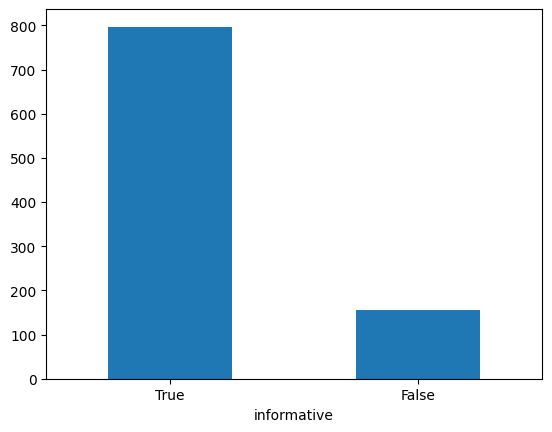

In [15]:
df_t1['informative'].value_counts().plot(kind='bar', rot=0)

In [16]:
# df_t1['humanitarian_label'].value_counts().plot(kind='bar')